# Predicting the 2026 FIFA World Cup: A Poisson-XGBoost Approach

### Dataset Source
The data used in this project is sourced from the [International football results from 1872 to the Present](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017) dataset on Kaggle, maintained by Mart Jürisoo. 

It contains over 49,000 historical men's international football results, which have been regularly updated to include recent matches.

### Objective
The goal of this notebook is to build a machine learning pipeline capable of predicting the outcomes of international football matches. Since standard classification models (Win/Loss) cannot simulate goal differentials required for tournament tie-breakers, this project uses XGBoost to predict Expected Goals (xG), which are then translated into exact match probabilities using a Bivariate Poisson distribution.

### Notebook Structure
This notebook is organized into the following sequential phases:
1. **Data Cleaning & Preprocessing:** Formatting dates, handling historical team name changes, and merging penalty shootout results.

2. **Feature Engineering:** Calculating chronological, continuous Elo ratings to measure baseline team strength and creating 5-game rolling momentum metrics.

3. **Exploratory Data Analysis (EDA):** Visualizing historical goal trends, home-field advantage, and scoreline distributions.

4. **Model Development:** Training the Home xG and Away xG XGBoost models using a strict chronological 3-way split.

5. **Model Evaluation:** Testing the models against the unseen 2022 FIFA World Cup to determine true baseline accuracy.

6. **The 2026 World Cup Simulation:** Deploying the trained models into a custom knockout bracket engine to simulate and predict the 2026 World Cup Champion.

### 1. Data Cleaning & Preprocessing

In [1]:
# Load main dataset
df <- read.csv("results.csv")

In [2]:
head(df)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
1,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,FALSE
2,1873-03-08,England,Scotland,4,2,Friendly,London,England,FALSE
3,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,FALSE
4,1875-03-06,England,Scotland,2,2,Friendly,London,England,FALSE
5,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,FALSE
6,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,FALSE


In [3]:
# Transform dates from strings to actual DATE objects
df$date <- as.Date(df$date)
# Add a year column
df$year <- as.numeric(format(df$date, "%Y"))
# Make logical columns numeric instead
df$neutral <- as.numeric(df$neutral)

In [4]:
head(df)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0,1872
2,1873-03-08,England,Scotland,4,2,Friendly,London,England,0,1873
3,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0,1874
4,1875-03-06,England,Scotland,2,2,Friendly,London,England,0,1875
5,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0,1876
6,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,0,1876


Based on the documentation, we need to address teams that have changed their names over time. We will use the `former_names.csv` dataset to ensure a country's historical timeline remains continuous.


In [5]:
former_names <- read.csv("former_names.csv")

In [6]:
head(former_names)

,current,former,start_date,end_date
,<chr>,<chr>,<chr>,<chr>
1,Benin,Dahomey,1959-11-08,1975-11-30
2,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
3,Curaao,Netherlands Antilles,1957-03-03,2010-10-10
4,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
5,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
6,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17


In [7]:
# Loop through the former names and update the main dataframe
for (i in seq_len(nrow(former_names))) {
    old_name <- former_names$former[i]
    new_name <- former_names$current[i]
    df$home_team[df$home_team == old_name] <- new_name
    df$away_team[df$away_team == old_name] <- new_name
}

In [8]:
# Checking for Null values
colSums(is.na(df))

date  home_team  away_team home_score away_score tournament       city 
         0          0          0          0          0          0          0 
   country    neutral       year 
         0          0          0

In knockout tournaments, drawn matches end in penalty shootouts. As we can see in the next cell, the initial dataset only tracks the score at the end of extra time, so we have no way of knowing who actually advanced. We will merge the `shootouts.csv` dataset to show the true winners.


In [9]:
df[df$date == "2022-12-18" & df$tournament == "FIFA World Cup", ]
# The table doesn't reflect that Argentina is the winner

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
45750,2022-12-18,Argentina,France,3,3,FIFA World Cup,Lusail,Qatar,1,2022


In [10]:
shootouts <- read.csv("shootouts.csv")
shootouts$date <- as.Date(shootouts$date)

In [11]:
head(shootouts)

,date,home_team,away_team,winner,first_shooter
,<date>,<chr>,<chr>,<chr>,<chr>
1,1967-08-22,India,Taiwan,Taiwan,
2,1971-11-14,South Korea,Vietnam Republic,South Korea,
3,1972-05-07,South Korea,Iraq,Iraq,
4,1972-05-17,Thailand,South Korea,South Korea,
5,1972-05-19,Thailand,Cambodia,Thailand,
6,1973-04-21,Senegal,Ghana,Ghana,


In [12]:
# Merge shootout data into the main dataframe (Left Join to keep regular matches)
df <- merge(df, shootouts[, c("date", "home_team", "away_team", "winner")], 
            by = c("date", "home_team", "away_team"), all.x = TRUE)

# Rename the merged column for clarity
names(df)[names(df) == "winner"] <- "shootout_winner"

In [13]:
df[df$date == "2022-12-18" & df$tournament == "FIFA World Cup", ]
# Now it's become clear who is the winner

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,shootout_winner
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
45750,2022-12-18,Argentina,France,3,3,FIFA World Cup,Lusail,Qatar,1,2022,Argentina


In [14]:
# Some rows will have null values which is expected since not every match ends in a penalty shootout
colSums(is.na(df))

date       home_team       away_team      home_score      away_score 
              0               0               0               0               0 
     tournament            city         country         neutral            year 
              0               0               0               0               0 
shootout_winner 
          48407

### 2. Feature Engineering

There are 191 unique tournaments in this dataset, but we want our model to emphasize the major ones. We will flag the World Cup and the major continental tournaments.

In [15]:
length(unique(df$tournament))

[1] 191

In [16]:
df[df$date == "2016-06-26" & df$home_team == "Argentina", ]
# NOTE: Because of the accent on e, Copa América isn't correctly displayed

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,shootout_winner
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
39904,2016-06-26,Argentina,Chile,0,0,Copa Amrica,East Rutherford,United States,1,2016,Chile


In [17]:
# \303\251 is the raw code for é character
major_tournaments <- c("FIFA World Cup", "UEFA Euro", "Copa Am\303\251rica", "African Cup of Nations", "AFC Asian Cup")
df$is_major_tournament <- ifelse(df$tournament %in% major_tournaments, 1, 0)

In [18]:
# Check if Copa América will be flagged as major
df[df$date == "2016-06-26" & df$home_team == "Argentina", ]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,shootout_winner,is_major_tournament
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
39904,2016-06-26,Argentina,Chile,0,0,Copa Amrica,East Rutherford,United States,1,2016,Chile,1


In [19]:
# Double check again:
# View the unique tournaments flagged as major
unique(df$tournament[df$is_major_tournament == 1])

[1] "Copa Am\303\251rica"    "FIFA World Cup"         "AFC Asian Cup"         
[4] "African Cup of Nations" "UEFA Euro"

In [20]:
# Add basic features such as total goals per match and goal difference
df$total_goals <- df$home_score + df$away_score
df$goal_diff <- df$home_score - df$away_score

# Add 2 temporary features, not used for modeling but will help with feature engineering
df$scoreline <- sprintf("%d-%d", df$home_score, df$away_score)
# Match outcome (1 = Home Win, 0 = Draw, -1 = Away Win)
df$match_outcome <- ifelse(df$home_score > df$away_score, 1,
                    ifelse(df$home_score == df$away_score, 0, -1))

To give our model an understanding of team strength, we will use the `elo` package to calculate continuous historical ratings.

In [21]:
library(elo)

In [22]:
# Define Home Field Advantage Bonus: If it's a true home game, give the host a 100-point boost
df$home_adv_adj <- ifelse(df$neutral == FALSE, 100, 0)

# Calculate continuous Elo ratings chronologically
# score tells the function who won based on the goals
# adjust() adds the 100 point bonus if there's a home advantage before updating the ratings
# home team and away team are the current elo rating before they get updated
elo_results <- elo.run(
  score(home_score, away_score) ~ adjust(home_team, home_adv_adj) + away_team, 
  data = df,
  k = 20 # K-factor dictates the maximum rating points gained/lost per match
)

elo_df <- as.data.frame(elo_results)

# Get pre-match Elos
df$home_elo_pre <- elo_df$elo.A - elo_df$update.A
df$away_elo_pre <- elo_df$elo.B - elo_df$update.B
df$elo_diff <- df$home_elo_pre - df$away_elo_pre

Note, as we will see below, these elo ratings aren't computed exactly the same way as FIFA computes them.

However, they match for the most part and preserve a ranking order

In [23]:
tail(df)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,shootout_winner,is_major_tournament,total_goals,goal_diff,scoreline,match_outcome,home_adv_adj,home_elo_pre,away_elo_pre,elo_diff
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,0,2026,NA,0,2,0,1-1,0,100,1597.507,1717.566,-120.05855
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,0,2026,NA,0,1,-1,0-1,-1,100,1352.878,1618.406,-265.52877
49068,2026-01-18,Morocco,Senegal,0,1,African Cup of Nations,Rabat,Morocco,0,2026,NA,1,1,-1,0-1,-1,100,1811.463,1814.475,-3.01189
49069,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,0,2026,NA,0,1,-1,0-1,-1,100,1716.989,1789.146,-72.15659
49070,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,0,2026,NA,0,1,-1,0-1,-1,100,1598.084,1799.946,-201.86144
49071,2026-01-26,Uzbekistan,China PR,2,2,Friendly,Dubai,United Arab Emirates,1,2026,NA,0,4,0,2-2,0,0,1719.632,1515.656,203.97599


In [24]:
# Let's take a look at the most recent Elo ratings
final_ratings <- final.elos(elo_results)
# Convert that named list into a clean dataframe
current_rankings <- data.frame(
  Team = names(final_ratings), 
  Rating = as.numeric(final_ratings)
)
# Sort it from highest rating to lowest
current_rankings <- current_rankings[order(-current_rankings$Rating), ]
rownames(current_rankings) <- NULL
head(current_rankings, 3)

,Team,Rating
,<chr>,<dbl>
1,Argentina,2007.036
2,Spain,1993.087
3,Brazil,1935.908


FIFA currently has the following top 3: Spain, France, Argentina

Adding 5-Game Rolling features

Teams constantly switch between being the "Home" team and the "Away" team. If we calculate momentum using only the `home_team` column, we miss a lot of their recent matches. To fix this, we will stack the home and away performances into a single, continuous timeline for each team.


In [25]:
# Assign Match Points (Win = 3, Draw = 1, Loss = 0)
df$home_points <- ifelse(df$home_score > df$away_score, 3, ifelse(df$home_score == df$away_score, 1, 0))
df$away_points <- ifelse(df$away_score > df$home_score, 3, ifelse(df$home_score == df$away_score, 1, 0))

# Create mini-dataframes from each team's perspective
home_stack <- data.frame(date = df$date, team = df$home_team, goals_scored = df$home_score, goals_conceded = df$away_score, points = df$home_points)
away_stack <- data.frame(date = df$date, team = df$away_team, goals_scored = df$away_score, goals_conceded = df$home_score, points = df$away_points)

# Stack and sort to create an uninterrupted historical timeline per team (because we sort by team's name first, then date)
team_perf <- rbind(home_stack, away_stack)
team_perf <- team_perf[order(team_perf$team, team_perf$date), ]

# Custom function to calculate the rolling sum of the previous 5 matches
calc_last_5 <- function(x) {
  n <- length(x)
  res <- numeric(n)
  if (n > 1) { 
    for (i in 2:n) {
      start_idx <- max(1, i - 5) 
      res[i] <- sum(x[start_idx:(i - 1)]) # Excludes the current match to prevent data leakage
    }
  }
  return(res)
}

# Apply the rolling sum to every team individually
teams_split <- split(team_perf, team_perf$team) # this will create a mini dataframe for each team individually
teams_split <- lapply(teams_split, function(tdf) {
  tdf$last_5_points <- calc_last_5(tdf$points)
  tdf$last_5_gs <- calc_last_5(tdf$goals_scored)
  tdf$last_5_gc <- calc_last_5(tdf$goals_conceded)
  return(tdf)
})
team_form <- do.call(rbind, teams_split) # stack them all together again

# Merge the momentum features (home and away) back to the main dataset
df <- merge(df, team_form[, c("date", "team", "last_5_points", "last_5_gs", "last_5_gc")], 
            by.x = c("date", "home_team"), by.y = c("date", "team"), all.x = TRUE)
names(df)[names(df) %in% c("last_5_points", "last_5_gs", "last_5_gc")] <- c("home_last_5_points", "home_last_5_gs", "home_last_5_gc")

df <- merge(df, team_form[, c("date", "team", "last_5_points", "last_5_gs", "last_5_gc")], 
            by.x = c("date", "away_team"), by.y = c("date", "team"), all.x = TRUE)

# Rename the columns so we know they belong to the Away team
names(df)[names(df) %in% c("last_5_points", "last_5_gs", "last_5_gc")] <- c("away_last_5_points", "away_last_5_gs", "away_last_5_gc")

In [26]:
head(df)

,date,away_team,home_team,home_score,away_score,tournament,city,country,neutral,year,...,away_elo_pre,elo_diff,home_points,away_points,home_last_5_points,home_last_5_gs,home_last_5_gc,away_last_5_points,away_last_5_gs,away_last_5_gc
,<date>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1872-11-30,England,Scotland,0,0,Friendly,Glasgow,Scotland,0,1872,...,1500.000,0.000000,1,1,0,0,0,0,0,0
2,1873-03-08,Scotland,England,4,2,Friendly,London,England,0,1873,...,1497.199,5.602600,3,0,1,0,0,1,0,0
3,1874-03-07,England,Scotland,2,1,Friendly,Glasgow,Scotland,0,1874,...,1509.852,-19.704159,3,0,1,2,4,4,4,2
4,1875-03-06,Scotland,England,2,2,Friendly,London,England,0,1875,...,1497.877,4.245787,1,1,4,5,4,4,4,5
5,1876-03-04,England,Scotland,3,0,Friendly,Glasgow,Scotland,0,1876,...,1499.209,1.581262,3,0,5,6,7,5,7,6
6,1876-03-25,Wales,Scotland,4,0,Friendly,Glasgow,Scotland,0,1876,...,1500.000,7.947444,3,0,8,9,7,0,0,0


### 3. Exploratory Data Analysis (EDA)

In [65]:
library(ggplot2)

`geom_smooth()` using formula = 'y ~ x'


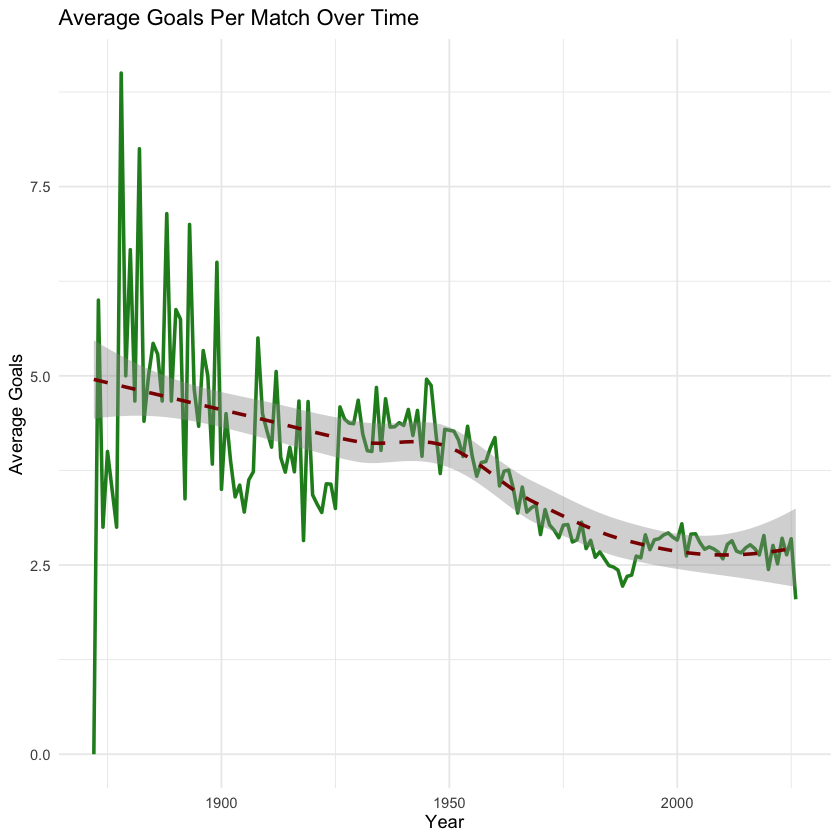

In [28]:
# Average number of goals per match over time
# aggregate() takes total_goals and groups them by each unique year
# FUN = mean tells R to calculate the average for each of those year groups
avg_goals_df <- aggregate(total_goals ~ year, data = df, FUN = mean)

plot_avg_goals <- ggplot(avg_goals_df, aes(x = year, y = total_goals)) +
  geom_line(color = "forestgreen", linewidth = 1) +
  geom_smooth(method = "loess", color = "darkred", linetype = "dashed") +
  labs(title = "Average Goals Per Match Over Time",
       x = "Year", y = "Average Goals") +
  theme_minimal()
print(plot_avg_goals)


**Conclusion:** High scoring in early football was too inconsistent to be reliable. To ensure our model doesn't over-predict goals, we will limit our training data to matches from 1998 onward, when scoring rates stabilized.

`geom_smooth()` using formula = 'y ~ x'


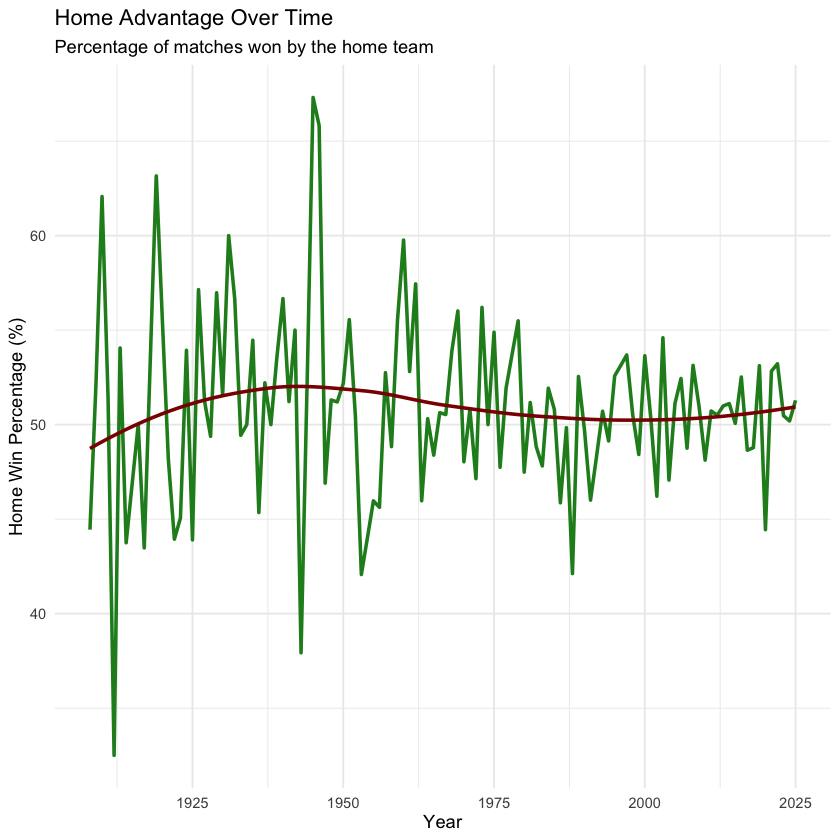

In [29]:
# Advantage of the host team over time (excluding neutral venues)
# Subset to non-neutral games
df_home <- df[df$neutral == FALSE, ]

# Calculate wins and total games per year
home_wins <- aggregate(match_outcome ~ year, data = df_home, FUN = function(x) sum(x == 1))
games_played <- aggregate(match_outcome ~ year, data = df_home, FUN = length)
home_adv_df <- merge(home_wins, games_played, by = "year")
names(home_adv_df) <- c("year", "wins", "total_games")
home_adv_df$home_win_pct <- (home_adv_df$wins / home_adv_df$total_games) * 100

# Filter out years with too few games to remove noise
home_adv_df <- home_adv_df[home_adv_df$total_games > 20, ]

plot_home_adv <- ggplot(home_adv_df, aes(x = year, y = home_win_pct)) +
  geom_line(color = "forestgreen", linewidth = 1) +
  geom_smooth(method = "loess", color = "darkred", se = FALSE) +
  labs(title = "Home Advantage Over Time",
       subtitle = "Percentage of matches won by the home team",
       x = "Year", y = "Home Win Percentage (%)") +
  theme_minimal()
print(plot_home_adv)

**Conclusion:** This graph proves that home advantage is real. Because the home team wins roughly 50% of the time in a sport with three possible outcomes, they hold an edge over the away team.

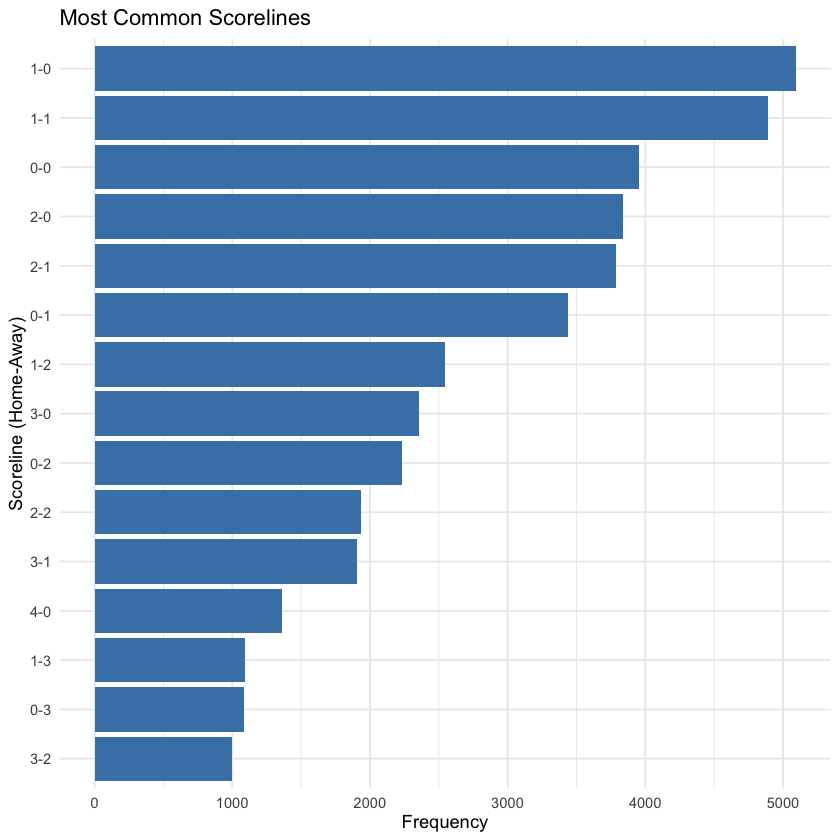

In [30]:
# Frequency of the most common results
scoreline_counts <- as.data.frame(table(df$scoreline))
names(scoreline_counts) <- c("scoreline", "count")
# Sort descending and grab the top 15
scoreline_counts <- scoreline_counts[order(-scoreline_counts$count), ]
scoreline_top15 <- head(scoreline_counts, 15)

plot_scorelines <- ggplot(scoreline_top15, aes(x = reorder(scoreline, count), y = count)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Most Common Scorelines",
       x = "Scoreline (Home-Away)", y = "Frequency") +
  theme_minimal()
print(plot_scorelines)

**Conclusion:** The most common scorelines are incredibly low, proving that goal data is heavily skewed. A standard linear regression would struggle with this because it's not a normal distribution, which is why we'll be using a Poisson distribution.

#### Final Dataset Preparation


In [31]:
# Keep only the features we need
cols_to_keep <- c("date", "tournament", "neutral", "is_major_tournament",
                  "home_team", "away_team", "home_score", "away_score", "total_goals", "goal_diff",
                  "home_elo_pre", "away_elo_pre", "elo_diff",
                  "home_last_5_points", "home_last_5_gs", "home_last_5_gc",
                  "away_last_5_points", "away_last_5_gs", "away_last_5_gc")

# Keep modern matches only (1998 onwards)
df_final <- df[df$year >= 1998, ]
df_final <- df_final[, cols_to_keep]

# 3-Way Time Split

# TRAIN: 1998 through 2017
train_df <- df_final[df_final$date < as.Date("2018-01-01"), ]

# VALIDATION: 2018 through Nov 19, 2022 (Before start of 2022 World Cup)
val_df   <- df_final[df_final$date >= as.Date("2018-01-01") & df_final$date < as.Date("2022-11-20"), ]

# TEST: Nov 20, 2022 onwards (From 2022 WC - Present)
test_df  <- df_final[df_final$date >= as.Date("2022-11-20"), ]

#### Feature Correlation Analysis

In [64]:
library(corrplot)

In [33]:
# Define the exact features the model is allowed to look at
# Notice we are EXCLUDING team names and dates
features <- c("neutral", "is_major_tournament", 
              "home_elo_pre", "away_elo_pre", "elo_diff",
              "home_last_5_points", "home_last_5_gs", "home_last_5_gc",
              "away_last_5_points", "away_last_5_gs", "away_last_5_gc")

In [34]:
# "complete.obs" safely ignores any accidental missing values
cor_matrix <- cor(train_df[, features], use = "complete.obs")

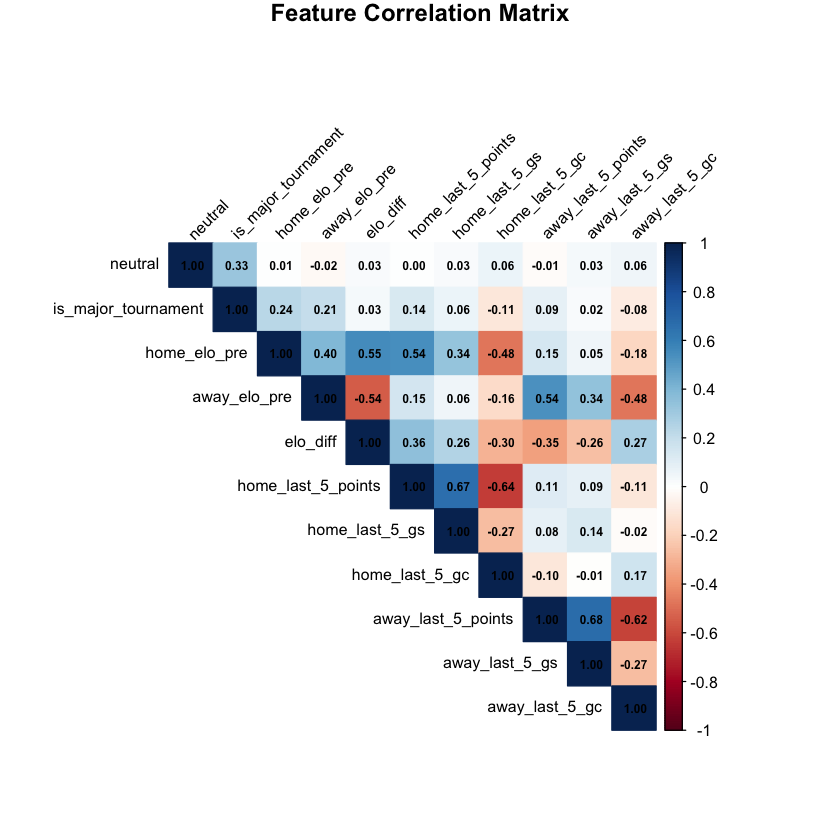

In [35]:
corrplot(cor_matrix, method = "color", type = "upper", # removes the redundant bottom half of the square
         tl.col = "black", tl.cex = 0.8, tl.srt = 45,
         addCoef.col = "black", number.cex = 0.6,
         title = "Feature Correlation Matrix", mar = c(0,0,1,0))

For both home and away games, a team's recent form (last_5_points) shows a strong positive correlation (0.69) with goals scored (last_5_gs) and a strong negative correlation (-0.64) with goals conceded (last_5_gc).

We also see natural correlations between a team's baseline Elo rating (home_elo_pre) and the overall match matchup difference (elo_diff) at 0.55.

Importantly, there are no correlations approaching 1.0 or -1.0 among our independent variables, meaning we do not have exact duplicate information in our dataset.

### 4. Model Development

A standard binary classification model (Win/Loss) is insufficient for simulating a World Cup tournament because it fails to capture goal differences required for ties. Furthermore, attempting to predict a single "Goal Difference" metric isn't enough because a +1 differential could represent a 1-0 or a 4-3 match.

To solve this, we use 2 XGBoost regressors with a Poisson objective function since goals are independent count events with a strict lower bound of zero and a heavy right-skew (as proven in the Exploratory Data Analysis):

Model 1 (Home xG): Predicts the Expected Goals scored by the Home team based on pre-match features.

Model 2 (Away xG): Predicts the Expected Goals scored by the Away team using the exact same feature set.

By generating two independent Expected Goal (xG) values for every matchup, we can use their Poisson distributions to calculate the precise percentage probability of exact whole-number scorelines.

To strictly prevent data leakage, the models were trained using a chronological 3-way split: Training (1998–2017), Validation for early stopping (2018–2022), and a Testing set (the 2022 FIFA World Cup and beyond) for final evaluation.

**Note on Model Selection:** Before developing our final simulation, we will first test a simple **Baseline Model** (predicting Home xG using only elo features) to prove the concept.  Our hypothesis is that an **Advanced Model** which has the 5-game rolling momentum features will outperform this baseline and reduce error.


In [66]:
library(xgboost)

In [37]:
# Set target variable
train_target_home <- train_df$home_score
train_target_away <- train_df$away_score

In [38]:
# Convert data into XGBoost's optimized DMatrix format
dtrain_home <- xgb.DMatrix(data = as.matrix(train_df[, features]), label = train_df$home_score)
dtrain_away <- xgb.DMatrix(data = as.matrix(train_df[, features]), label = train_df$away_score)

dval_home <- xgb.DMatrix(data = as.matrix(val_df[, features]), label = val_df$home_score)
dval_away <- xgb.DMatrix(data = as.matrix(val_df[, features]), label = val_df$away_score)

dtest_home <- xgb.DMatrix(data = as.matrix(test_df[, features]), label = test_df$home_score)
dtest_away <- xgb.DMatrix(data = as.matrix(test_df[, features]), label = test_df$away_score)

In [ ]:
# MAIN MODEL TRAINING
# Setup standard parameters for a Poisson regression
xgb_params <- list(
  objective = "count:poisson", # Tells the model we are predicting counts (goals)
  eval_metric = "poisson-nloglik", # Standard evaluation metric for Poisson
  eta = 0.05,                  # Learning rate (how fast it learns; 0.05 is nice and slow)
  max_depth = 4,               # How complex the decision trees can get
  subsample = 0.8,             # Use 80% of data per tree to prevent overfitting
  colsample_bytree = 0.8       # Use 80% of features per tree
)

In [40]:
# Train the Home Model
model_home <- xgb.train(
  params = xgb_params,
  data = dtrain_home,
  nrounds = 500, # build 500 decision trees to refine its accuracy
  evals = list(train = dtrain_home, val = dval_home),
  early_stopping_rounds = 20, # Stops early if it stops improving (saves time and prevents overfitting)
  print_every_n = 50          # Don't spam the console, just print every 50 steps
)

Multiple eval metrics are present. Will use val_poisson_nloglik for early stopping.
Will train until val_poisson_nloglik hasn't improved in 20 rounds.

[1]	train-poisson-nloglik:1.781530	val-poisson-nloglik:1.749299 
[51]	train-poisson-nloglik:1.607666	val-poisson-nloglik:1.573603 
[101]	train-poisson-nloglik:1.579405	val-poisson-nloglik:1.546225 
[151]	train-poisson-nloglik:1.569006	val-poisson-nloglik:1.539573 
[201]	train-poisson-nloglik:1.562354	val-poisson-nloglik:1.537491 
Stopping. Best iteration:
[244]	train-poisson-nloglik:1.557822	val-poisson-nloglik:1.536992

[244]	train-poisson-nloglik:1.557822	val-poisson-nloglik:1.536992 


In [41]:
# Train the Away Model
model_away <- xgb.train(
  params = xgb_params,
  data = dtrain_away,
  nrounds = 500,
  evals = list(train = dtrain_away, val = dval_away),
  early_stopping_rounds = 20,
  print_every_n = 50
)

Multiple eval metrics are present. Will use val_poisson_nloglik for early stopping.
Will train until val_poisson_nloglik hasn't improved in 20 rounds.

[1]	train-poisson-nloglik:1.482893	val-poisson-nloglik:1.464441 
[51]	train-poisson-nloglik:1.352339	val-poisson-nloglik:1.332226 
[101]	train-poisson-nloglik:1.325721	val-poisson-nloglik:1.309533 
[151]	train-poisson-nloglik:1.316382	val-poisson-nloglik:1.304531 
[201]	train-poisson-nloglik:1.310807	val-poisson-nloglik:1.303001 
[251]	train-poisson-nloglik:1.306034	val-poisson-nloglik:1.302140 
Stopping. Best iteration:
[268]	train-poisson-nloglik:1.304719	val-poisson-nloglik:1.302192

[268]	train-poisson-nloglik:1.304719	val-poisson-nloglik:1.302192 


In [42]:
# Feature Importance Plots
importance_matrix_home <- xgb.importance(feature_names = features, model = model_home)
importance_matrix_away <- xgb.importance(feature_names = features, model = model_away)

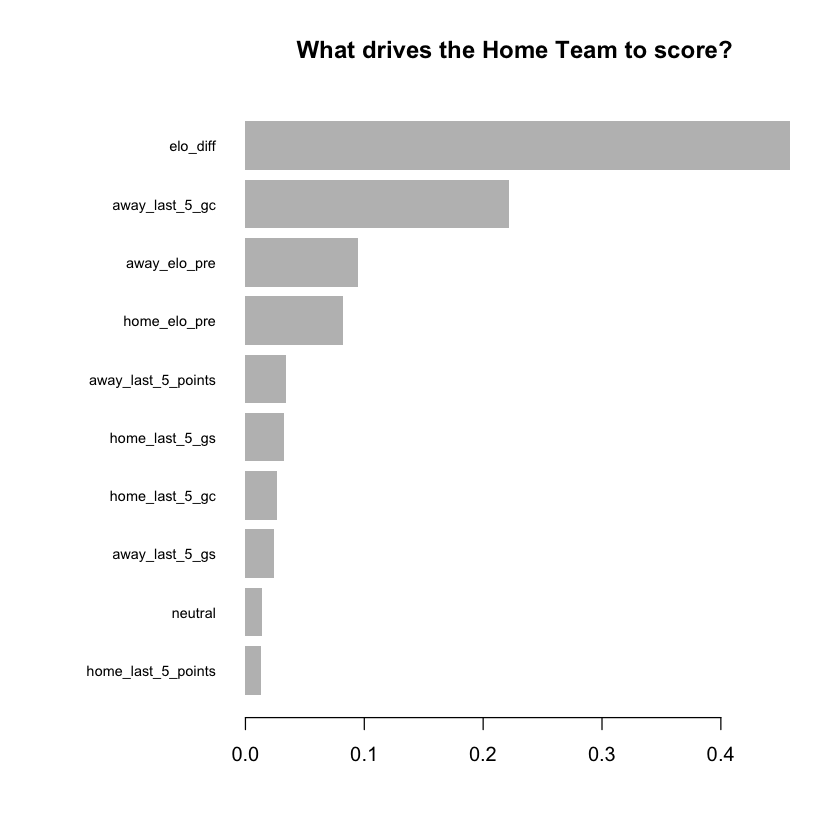

In [43]:
xgb.plot.importance(importance_matrix_home, top_n = 10, measure = "Gain",
                    main = "What drives the Home Team to score?")


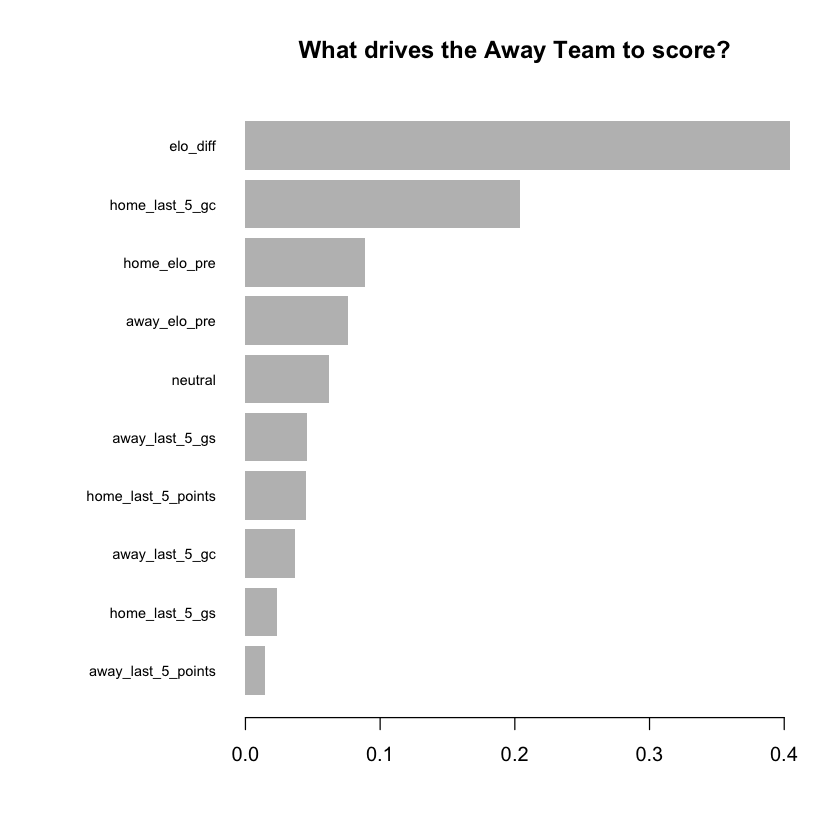

In [44]:
xgb.plot.importance(importance_matrix_away, top_n = 10, measure = "Gain",
                    main = "What drives the Away Team to score?")

**The Dominance of Elo Difference:** In both models, elo_diff is by far the most significant driver of goal prediction, accounting for nearly 50% of the information gain. This proves that the relative strength gap between the two teams dictates the flow of the match more than any other variable. Although our custom `elo` calculation differs from the proprietary FIFA rankings, it still proved to be the most useful for the model.

**The "Bad Defense" Insight:** The second most important feature for predicting a team's goals isn't their own offensive momentum, but rather their opponent's defensive vulnerability. The Home model relies heavily on away_last_5_gc (goals conceded by the away team), and the Away model relies on home_last_5_gc.



In [80]:
# THIS IS A BASELINE Model for comparison only. It only uses elo features
features_baseline <- c("home_elo_pre", "away_elo_pre", "elo_diff")

dtrain_home_baseline <- xgb.DMatrix(data = as.matrix(train_df[, features_baseline]), label = train_df$home_score)
dval_home_baseline <- xgb.DMatrix(data = as.matrix(val_df[, features_baseline]), label = val_df$home_score)
dtest_home_baseline <- xgb.DMatrix(data = as.matrix(test_df[, features_baseline]), label = test_df$home_score)

# Trained exactly the same way as the main model
model_home_baseline <- xgb.train(
  params = xgb_params,
  data = dtrain_home_baseline,
  nrounds = 500,
  evals = list(train = dtrain_home_baseline, val = dval_home_baseline),
  early_stopping_rounds = 20,
  print_every_n = 50
)

Multiple eval metrics are present. Will use val_poisson_nloglik for early stopping.
Will train until val_poisson_nloglik hasn't improved in 20 rounds.

[1]	train-poisson-nloglik:1.782383	val-poisson-nloglik:1.750006 
[51]	train-poisson-nloglik:1.639460	val-poisson-nloglik:1.591212 
[101]	train-poisson-nloglik:1.622020	val-poisson-nloglik:1.573291 
[151]	train-poisson-nloglik:1.616574	val-poisson-nloglik:1.570542 
[201]	train-poisson-nloglik:1.612883	val-poisson-nloglik:1.570230 
Stopping. Best iteration:
[205]	train-poisson-nloglik:1.612583	val-poisson-nloglik:1.570261

[205]	train-poisson-nloglik:1.612583	val-poisson-nloglik:1.570261 


### 5. Model Evaluation

In [81]:
# The model spits out a decimal (e.g., 1.45 goals)
test_df$pred_home_xg <- predict(model_home, dtest_home)
test_df$pred_away_xg <- predict(model_away, dtest_away)
# Test Baseline RMSE
pred_baseline <- predict(model_home_baseline, dtest_home_baseline)

In [82]:
# Calculate the Error Metrics (RMSE - Root Mean Squared Error)
# RMSE tells us, on average, how many goals our prediction was off by
rmse_home <- sqrt(mean((test_df$home_score - test_df$pred_home_xg)^2))
rmse_away <- sqrt(mean((test_df$away_score - test_df$pred_away_xg)^2))
rmse_baseline <- sqrt(mean((test_df$home_score - pred_baseline)^2))

In [79]:
rmse_home
rmse_away
rmse_baseline

[1] 1.396743

[1] 1.141193

[1] 1.428545

**Conclusion on Model Selection:** As hypothesized, the Advanced Home xG Model (RMSE: 1.397) outperformed the Baseline Home xG Model (RMSE: 1.429).

In [48]:
# Print the first 10 World Cup matches
sample_matches <- test_df[test_df$tournament == "FIFA World Cup", 
                          c("home_team", "away_team", "home_score", "away_score", "pred_home_xg", "pred_away_xg")]
sample_matches$pred_home_xg <- round(sample_matches$pred_home_xg, 3)
sample_matches$pred_away_xg <- round(sample_matches$pred_away_xg, 3)
print(head(sample_matches, 10), row.names = FALSE)

     home_team    away_team home_score away_score pred_home_xg pred_away_xg
         Qatar      Ecuador          0          2        1.148        1.050
       England         Iran          6          2        1.341        1.193
       Senegal  Netherlands          0          2        0.914        1.734
 United States        Wales          1          1        1.505        0.943
        France    Australia          4          1        1.682        0.871
        Mexico       Poland          0          0        1.373        0.978
     Argentina Saudi Arabia          1          2        2.442        0.534
       Denmark      Tunisia          0          0        1.504        0.943
       Belgium       Canada          1          0        1.692        0.844
         Spain   Costa Rica          7          0        1.867        0.796


In [49]:
# Poisson Match Simulator Function
# This function takes the Home xG and Away xG, and returns the % chance of W/D/L
simulate_match <- function(home_xg, away_xg) {
  max_goals = 7
  # Calculate exact probabilities for scoring 0 through 7 goals
  home_probs <- dpois(0:max_goals, home_xg)
  away_probs <- dpois(0:max_goals, away_xg)
  
  # Create a matrix of every possible scoreline combination
  score_matrix <- outer(home_probs, away_probs)
  
  # Sum the matrix regions
  # Lower triangle = Home scores more than Away (Home Win)
  home_win_prob <- sum(score_matrix[lower.tri(score_matrix)])
  # Diagonal = Both score the same (Draw)
  draw_prob <- sum(diag(score_matrix))
  # Upper triangle = Away scores more than Home (Away Win)
  away_win_prob <- sum(score_matrix[upper.tri(score_matrix)])
  
  return(c(Home_Win = home_win_prob, Draw = draw_prob, Away_Win = away_win_prob))
}

In [50]:
world_cup_2022 <- test_df[test_df$date >= as.Date("2022-11-20") & test_df$date <= as.Date("2022-12-18") & test_df$tournament == "FIFA World Cup", ]

In [51]:
# Apply the Simulator to every match in our 2022 Test Set
match_probs <- t(mapply(simulate_match, world_cup_2022$pred_home_xg, world_cup_2022$pred_away_xg))

In [52]:
# Attach the probabilities
world_cup_2022$prob_home_win <- match_probs[, 1]
world_cup_2022$prob_draw <- match_probs[, 2]
world_cup_2022$prob_away_win <- match_probs[, 3]

In [53]:
# Determine the Model's Official Pick
# The model chooses whichever outcome has the highest probability
world_cup_2022$model_pick <- ifelse(world_cup_2022$prob_home_win > world_cup_2022$prob_draw & world_cup_2022$prob_home_win > world_cup_2022$prob_away_win, 1,
                      ifelse(world_cup_2022$prob_away_win > world_cup_2022$prob_home_win & world_cup_2022$prob_away_win > world_cup_2022$prob_draw, -1, 0))

# Determine the Actual Truth
world_cup_2022$actual_outcome <- ifelse(world_cup_2022$home_score > world_cup_2022$away_score, 1,
                          ifelse(world_cup_2022$home_score < world_cup_2022$away_score, -1, 0))

In [54]:
# Accuracy
correct_picks <- sum(world_cup_2022$model_pick == world_cup_2022$actual_outcome)
total_matches <- nrow(world_cup_2022)
accuracy_pct <- (correct_picks / total_matches) * 100

In [55]:
accuracy_pct

[1] 53.125

In [56]:
# 2022 WORLD CUP FINAL PREDICTION
wc_final <- world_cup_2022[world_cup_2022$date == as.Date("2022-12-18"), ]
cat(sprintf("Matchup: %s vs %s\n", wc_final$home_team, wc_final$away_team))
cat(sprintf("Model Expected Goals: %.2f - %.2f\n", wc_final$pred_home_xg, wc_final$pred_away_xg))
cat(sprintf("Win Probability: %s (%.1f%%) | Draw (%.1f%%) | %s (%.1f%%)\n", 
            wc_final$home_team, wc_final$prob_home_win * 100, 
            wc_final$prob_draw * 100, 
            wc_final$away_team, wc_final$prob_away_win * 100))
cat(sprintf("Actual Score: %d - %d\n", wc_final$home_score, wc_final$away_score))

Matchup: Argentina vs France
Model Expected Goals: 1.34 - 1.51
Win Probability: Argentina (33.5%) | Draw (24.9%) | France (41.5%)
Actual Score: 3 - 3


* **Model Performance:** The model achieved **53.1% accuracy** on the unseen 2022 World Cup dataset. In a low-scoring, 3-outcome sport (Win/Draw/Loss) where a random guess is 33% and professional sportsbooks operate around 55%, this is a successful result.

* **Limitations and Future Work:** The model relies purely on the team history and doesn't take into account micro-level features such as star player injuries. In a subsequent project, I would improve the model by integrating player-level statistics.

### 6. For Fun: The 2026 World Cup Simulation

2026 is the first year FIFA is expanding the tournament to 48 teams (12 groups of 4). The top 2 from each group advance, plus the 8 best 3rd-place teams. 

Simulating this would require an excessive amount of custom tie breaking code, so I opted to strictly simulate the knockout stage given 32 teams of my choice.

In [57]:
# Grab a team's most recent momentum stats
get_latest_stats <- function(team_name) {
  # Find all matches this team played
  team_data <- df_final[df_final$home_team == team_name | df_final$away_team == team_name, ]  
  # Grab their chronologically final match
  last_match <- tail(team_data, 1)
  
  # Return their momentum depending on if they were Home or Away in that final match
  if(last_match$home_team == team_name) {
    return(c(last_match$home_last_5_points, last_match$home_last_5_gs, last_match$home_last_5_gc))
  } else {
    return(c(last_match$away_last_5_points, last_match$away_last_5_gs, last_match$away_last_5_gc))
  }
}

# Main Simulator Function
get_winner <- function(team_A, team_B) {
  # Because 2026 is in North America, we treat matches as neutral (1)
  # UNLESS USA, Canada, or Mexico are playing
  hosts <- c("United States", "Canada", "Mexico")
  neutral_venue <- ifelse(team_A %in% hosts | team_B %in% hosts, 0, 1)
  
  # Get latest Elo ratings
  elo_A <- as.numeric(final_ratings[team_A])
  elo_B <- as.numeric(final_ratings[team_B])
  
  # Get latest momentum stats
  stats_A <- get_latest_stats(team_A)
  stats_B <- get_latest_stats(team_B)
  
  # Build a 1-row dataframe that perfectly matches our XGBoost training features
  future_match <- data.frame(
    neutral = neutral_venue, is_major_tournament = 1,
    home_elo_pre = elo_A, away_elo_pre = elo_B, elo_diff = elo_A - elo_B,
    home_last_5_points = stats_A[1], home_last_5_gs = stats_A[2], home_last_5_gc = stats_A[3],
    away_last_5_points = stats_B[1], away_last_5_gs = stats_B[2], away_last_5_gc = stats_B[3]
  )
  # Convert to XGBoost Matrix format
  features <- colnames(future_match)
  d_future <- xgb.DMatrix(data = as.matrix(future_match[, features]))
  
  # Run through the Poisson simulator to get percentages
  probs <- simulate_match(predict(model_home, d_future), predict(model_away, d_future))
  
  # In the knockout stage, there are no draws. If the model predicts a draw as the 
  # highest probability, we give the win to the team with the higher chance of an outright win
  if (probs["Home_Win"] >= probs["Away_Win"]) { return(team_A) } else { return(team_B) }
}

# Define the Simulation Loop
simulate_round <- function(teams, round_name) {
  cat(sprintf("\n--- %s ---\n", round_name))
  winners <- c()
  
  # Loop through the list 2 teams at a time
  for (i in seq(1, length(teams), by = 2)) {
    team_A <- teams[i]
    team_B <- teams[i+1]
    
    winner <- get_winner(team_A, team_B)
    winners <- c(winners, winner)
    
    cat(sprintf("%s vs %s  ->  Winner: %s\n", team_A, team_B, winner))
  }
  return(winners)
}

In [58]:
# My list of 2026 Round of 32 Matchups (after I simulated the group stage by hand)
# Every pair of teams (each line) represents a single matchup (e.g., Germany vs. Paraguay)
# The winner of Line 1 will automatically play the winner of Line 2 in the next round

# My list of 2026 Round of 32 Matchups
# Quadrants 1 & 2 will meet in Semi-Final 1
# Quadrants 3 & 4 will meet in Semi-Final 2

round_of_32 <- c(
  # =============================================
  # TOP HALF OF THE BRACKET (Produces Finalist 1)
  # =============================================

  # Quadrant 1
  "Germany", "Paraguay",
  "France", "Tunisia",
  "South Africa", "Canada",
  "Netherlands", "Morocco",

  # Quadrant 2
  "Colombia", "Croatia",
  "Spain", "Algeria",
  "United States", "Norway",
  "Belgium", "South Korea",

  # ================================================
  # BOTTOM HALF OF THE BRACKET (Produces Finalist 2)
  # ================================================

  # Quadrant 3
  "Brazil", "Japan",
  "Ivory Coast", "Senegal",
  "Mexico", "Cape Verde",
  "England", "DR Congo",

  # Quadrant 4
  "Argentina", "Uruguay",
  "Turkey", "Egypt",
  "Switzerland", "Austria",
  "Portugal", "Ghana"
)

In [59]:
# RUN THE BRACKET
round_of_16    <- simulate_round(round_of_32, "ROUND OF 32")


--- ROUND OF 32 ---
Germany vs Paraguay  ->  Winner: Germany
France vs Tunisia  ->  Winner: France
South Africa vs Canada  ->  Winner: Canada
Netherlands vs Morocco  ->  Winner: Netherlands
Colombia vs Croatia  ->  Winner: Colombia
Spain vs Algeria  ->  Winner: Spain
United States vs Norway  ->  Winner: United States
Belgium vs South Korea  ->  Winner: Belgium
Brazil vs Japan  ->  Winner: Brazil
Ivory Coast vs Senegal  ->  Winner: Senegal
Mexico vs Cape Verde  ->  Winner: Mexico
England vs DR Congo  ->  Winner: England
Argentina vs Uruguay  ->  Winner: Argentina
Turkey vs Egypt  ->  Winner: Turkey
Switzerland vs Austria  ->  Winner: Switzerland
Portugal vs Ghana  ->  Winner: Portugal


In [60]:
quarter_finals <- simulate_round(round_of_16, "ROUND OF 16")


--- ROUND OF 16 ---
Germany vs France  ->  Winner: France
Canada vs Netherlands  ->  Winner: Canada
Colombia vs Spain  ->  Winner: Spain
United States vs Belgium  ->  Winner: Belgium
Brazil vs Senegal  ->  Winner: Brazil
Mexico vs England  ->  Winner: England
Argentina vs Turkey  ->  Winner: Argentina
Switzerland vs Portugal  ->  Winner: Portugal


In [61]:
semi_finals    <- simulate_round(quarter_finals, "QUARTER-FINALS")


--- QUARTER-FINALS ---
France vs Canada  ->  Winner: France
Spain vs Belgium  ->  Winner: Spain
Brazil vs England  ->  Winner: Brazil
Argentina vs Portugal  ->  Winner: Portugal


In [62]:
final_match    <- simulate_round(semi_finals, "SEMI-FINALS")


--- SEMI-FINALS ---
France vs Spain  ->  Winner: Spain
Brazil vs Portugal  ->  Winner: Brazil


In [63]:
champion       <- simulate_round(final_match, "WORLD CUP FINAL")


--- WORLD CUP FINAL ---
Spain vs Brazil  ->  Winner: Spain
